# SKU holdout review (2026-05-02..2026-05-12, 11 дней)

**Метод**: bakery-day holdout-прогноз → распределён по SKU через share-профили (raw и smoothed) → сравнён с фактом из чеков, отмасштабированным к `Продано`-уровню per (date, bakery).

**Источник**: `reports/holdout_sku_compare.csv` (526446 строк, 182 пекарни, 1145 продуктов, 11 дней).

**Окно**: пересечение bakery-holdout (05-02..05-31) и SKU-факта eval30d (04-13..05-12) = 05-02..05-12.

**Важно**: SKU-прогноз = bakery_day_forecast × sku_day_share. Аллокация **детерминированная** — это не отдельная модель, а профильная разбивка. Поэтому ошибка SKU = (ошибка bakery) + (ошибка профиля). Здесь мы смотрим в основном на вторую.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_CSV = REPO_ROOT / "reports" / "holdout_sku_compare.csv"
PRODUCT_LOOKUP = REPO_ROOT / "data" / "processed" / "product_lookup.csv"
CHARTS_DIR = REPO_ROOT / "reports" / "holdout_sku_charts"
CHARTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_CSV, parse_dates=["date"])
products = pd.read_csv(PRODUCT_LOOKUP)
df = df.merge(products, on="product_id", how="left")

print(f"rows:      {len(df)}")
print(f"bakeries:  {df['bakery_id'].nunique()}")
print(f"products:  {df['product_id'].nunique()}")
print(f"days:      {df['date'].nunique()}")
print(f"date range:{df['date'].min().date()} .. {df['date'].max().date()}")
df.head()

rows:      526446
bakeries:  182
products:  1145
days:      11
date range:2026-05-02 .. 2026-05-12


,date,bakery_id,bakery_name,city,product_id,fact,forecast_raw,forecast_smoothed,err_raw,err_smoothed,abs_err_raw,abs_err_smoothed,product_name,category_name
0,2026-05-02,1,Столичная 37А Зеленодольск,Зеленодольск,5,1.852121,2.603382,2.611277,0.751261,0.759156,0.751261,0.759156,Зерновой,Хлеб
1,2026-05-03,1,Столичная 37А Зеленодольск,Зеленодольск,5,1.794405,2.974622,2.908125,1.180217,1.113720,1.180217,1.113720,Зерновой,Хлеб
2,2026-05-04,1,Столичная 37А Зеленодольск,Зеленодольск,5,2.806340,3.504923,3.536080,0.698583,0.729740,0.698583,0.729740,Зерновой,Хлеб
3,2026-05-05,1,Столичная 37А Зеленодольск,Зеленодольск,5,1.878520,3.705808,3.659310,1.827288,1.780789,1.827288,1.780789,Зерновой,Хлеб
4,2026-05-06,1,Столичная 37А Зеленодольск,Зеленодольск,5,1.893229,3.159774,3.157417,1.266545,1.264188,1.266545,1.264188,Зерновой,Хлеб


## 1. Структура ячеек (fact × forecast)

Сначала просто видим, в каких «клетках» лежит ошибка. Это первое и самое важное наблюдение.

In [2]:
EPS = 0.001
fc_pos = df["forecast_raw"] > EPS
fact_pos = df["fact"] > EPS

buckets = {
    "both > 0 (real allocation)":  fc_pos & fact_pos,
    "forecast > 0, fact = 0":      fc_pos & ~fact_pos,
    "forecast = 0, fact > 0":      ~fc_pos & fact_pos,
    "both = 0 (noise)":            ~fc_pos & ~fact_pos,
}

rows = []
for name, mask in buckets.items():
    rows.append({
        "bucket": name,
        "rows":   int(mask.sum()),
        "rows_%": mask.mean() * 100,
        "sum_fact":     df.loc[mask, "fact"].sum(),
        "sum_forecast_raw":  df.loc[mask, "forecast_raw"].sum(),
        "abs_err_raw":     df.loc[mask, "abs_err_raw"].sum(),
    })
table_cells = pd.DataFrame(rows)
total_err = table_cells["abs_err_raw"].sum()
table_cells["err_%"] = table_cells["abs_err_raw"] / total_err * 100
table_cells.round(2)

,bucket,rows,rows_%,sum_fact,sum_forecast_raw,abs_err_raw,err_%
0,both > 0 (real allocation),226600,43.04,1790926.79,1127379.57,1063284.25,58.91
1,"forecast > 0, fact = 0",299840,56.96,0.00,741510.41,741510.41,41.09
2,"forecast = 0, fact > 0",0,0.00,0.00,0.00,0.00,0.00
3,both = 0 (noise),6,0.00,0.00,0.01,0.01,0.00


## 2. Aggregate-метрики

WMAPE на всех 526k строках (включая пустые корзины) — наглядно отражает реальное качество профильной аллокации.

In [3]:
def metrics(d):
    f = d["fact"].sum()
    return pd.Series({
        "rows":       len(d),
        "sum_fact":   f,
        "sum_fc_raw":      d["forecast_raw"].sum(),
        "sum_fc_smoothed": d["forecast_smoothed"].sum(),
        "MAE_raw":         d["abs_err_raw"].mean(),
        "MAE_smoothed":    d["abs_err_smoothed"].mean(),
        "WMAPE_raw":       d["abs_err_raw"].sum() / max(f, 1) * 100,
        "WMAPE_smoothed":  d["abs_err_smoothed"].sum() / max(f, 1) * 100,
        "bias_raw":        d["err_raw"].mean(),
        "bias_smoothed":   d["err_smoothed"].mean(),
    })

print("== ALL rows ==")
print(metrics(df).round(4))
print()
print("== Only fact > 0 (excludes empty buckets) ==")
print(metrics(df[df["fact"] > EPS]).round(4))
print()
print("== Only both > 0 (excludes also out-of-profile) ==")
print(metrics(df[(df["fact"] > EPS) & (df["forecast_raw"] > EPS)]).round(4))

== ALL rows ==
rows               5.264460e+05
sum_fact           1.790927e+06
sum_fc_raw         1.868890e+06
sum_fc_smoothed    1.868890e+06
MAE_raw            3.428300e+00
MAE_smoothed       3.384900e+00
WMAPE_raw          1.007743e+02
WMAPE_smoothed     9.950030e+01
bias_raw           1.481000e-01
bias_smoothed      1.481000e-01
dtype: float64

== Only fact > 0 (excludes empty buckets) ==
rows               2.266000e+05
sum_fact           1.790927e+06
sum_fc_raw         1.127380e+06
sum_fc_smoothed    1.160334e+06
MAE_raw            4.692300e+00
MAE_smoothed       4.737100e+00
WMAPE_raw          5.937060e+01
WMAPE_smoothed     5.993660e+01
bias_raw          -2.928300e+00
bias_smoothed     -2.782800e+00
dtype: float64

== Only both > 0 (excludes also out-of-profile) ==
rows               2.266000e+05
sum_fact           1.790927e+06
sum_fc_raw         1.127380e+06
sum_fc_smoothed    1.160334e+06
MAE_raw            4.692300e+00
MAE_smoothed       4.737100e+00
WMAPE_raw          5.9370

## 3. По дням окна

C:\Users\dns\AppData\Local\Temp\ipykernel_15800\2941930905.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_day = df.groupby("date", group_keys=False).apply(


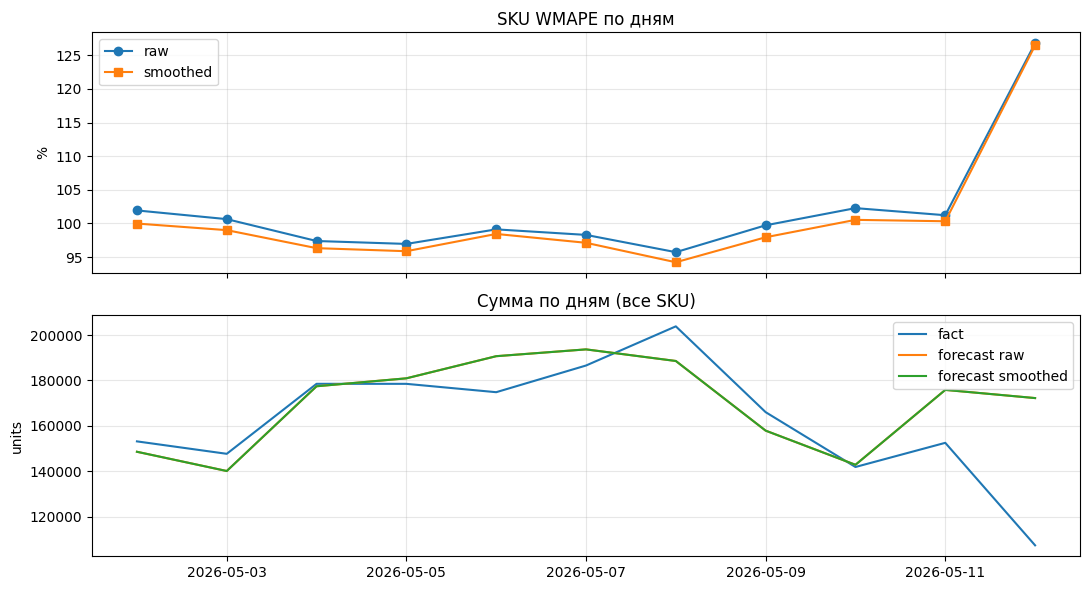

,date,fact,fc_raw,fc_smooth,wmape_raw,wmape_smooth
0,2026-05-02,153156.99,148577.65,148577.65,101.94,99.99
1,2026-05-03,147675.85,140092.66,140092.66,100.65,99.01
2,2026-05-04,178530.01,177450.33,177450.33,97.39,96.33
3,2026-05-05,178517.47,180951.39,180951.39,96.96,95.88
4,2026-05-06,174835.61,190704.05,190704.05,99.12,98.44
5,2026-05-07,186593.52,193707.08,193707.08,98.30,97.13
6,2026-05-08,203859.25,188592.05,188592.05,95.73,94.23
7,2026-05-09,166034.11,157890.42,157890.42,99.73,97.95
8,2026-05-10,141867.91,142834.99,142834.99,102.28,100.54
9,2026-05-11,152519.71,175847.23,175847.23,101.23,100.33


In [4]:
by_day = df.groupby("date", group_keys=False).apply(
    lambda g: pd.Series({
        "fact":       g["fact"].sum(),
        "fc_raw":     g["forecast_raw"].sum(),
        "fc_smooth":  g["forecast_smoothed"].sum(),
        "wmape_raw":      g["abs_err_raw"].sum() / max(g["fact"].sum(), 1) * 100,
        "wmape_smooth":   g["abs_err_smoothed"].sum() / max(g["fact"].sum(), 1) * 100,
    })
).reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax1.plot(by_day["date"], by_day["wmape_raw"],    marker="o", label="raw")
ax1.plot(by_day["date"], by_day["wmape_smooth"], marker="s", label="smoothed")
ax1.set_title("SKU WMAPE по дням"); ax1.set_ylabel("%"); ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(by_day["date"], by_day["fact"],      label="fact")
ax2.plot(by_day["date"], by_day["fc_raw"],    label="forecast raw")
ax2.plot(by_day["date"], by_day["fc_smooth"], label="forecast smoothed")
ax2.set_title("Сумма по дням (все SKU)"); ax2.set_ylabel("units"); ax2.legend(); ax2.grid(alpha=0.3)
fig.tight_layout(); plt.show()
by_day.round(2)

## 4. По категориям

In [5]:
by_cat = df.groupby("category_name", group_keys=False, dropna=False).apply(
    lambda g: pd.Series({
        "rows": len(g),
        "products":  g["product_id"].nunique(),
        "sum_fact":  g["fact"].sum(),
        "sum_fc_raw":      g["forecast_raw"].sum(),
        "wmape_raw":       g["abs_err_raw"].sum() / max(g["fact"].sum(), 1) * 100,
        "wmape_smoothed":  g["abs_err_smoothed"].sum() / max(g["fact"].sum(), 1) * 100,
        "bias_raw":        g["err_raw"].sum(),
    })
).sort_values("sum_fact", ascending=False)
by_cat.round(2).head(20)

C:\Users\dns\AppData\Local\Temp\ipykernel_15800\4231560767.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_cat = df.groupby("category_name", group_keys=False, dropna=False).apply(


,rows,products,sum_fact,sum_fc_raw,wmape_raw,wmape_smoothed,bias_raw
category_name,,,,,,,
Выпечка сытная,49184.0,68.0,779870.71,406353.20,73.08,73.32,-373517.51
Выпечка сладкая,39404.0,53.0,237760.21,204210.07,87.67,87.99,-33550.14
Хлеб,34255.0,91.0,138620.40,130054.33,68.16,70.72,-8566.06
Фастфуд,30958.0,83.0,124641.84,115196.28,72.30,72.73,-9445.57
Пирожные,77282.0,108.0,116029.23,288805.04,192.42,192.59,172775.81
Пироги сладкие,43243.0,38.0,113481.94,145136.08,109.56,110.70,31654.13
Прочие товары,26986.0,43.0,85105.73,70511.24,105.80,102.27,-14594.48
Напитки горячие,40606.0,48.0,83134.06,123707.61,109.32,104.27,40573.55
Пироги сытные,26088.0,34.0,40723.32,75293.35,121.52,116.28,34570.02


## 5. «Мёртвые» SKU: профиль ждёт, факт=0 все 11 дней

Это 41% всей ошибки. Скорее всего — продукты, снятые с ассортимента в конкретных пекарнях, но всё ещё лежащие в профиле.

In [6]:
by_pair = df.groupby(["bakery_id", "product_id"], group_keys=False).apply(
    lambda g: pd.Series({
        "days_with_fact":     int((g["fact"] > EPS).sum()),
        "days_with_forecast": int((g["forecast_raw"] > EPS).sum()),
        "sum_fact":     g["fact"].sum(),
        "sum_fc_raw":   g["forecast_raw"].sum(),
        "mean_fact":    g["fact"].mean(),
        "mean_fc_raw":  g["forecast_raw"].mean(),
    })
).reset_index()
by_pair = by_pair.merge(products, on="product_id", how="left")
by_pair = by_pair.merge(
    df[["bakery_id", "bakery_name", "city"]].drop_duplicates("bakery_id"),
    on="bakery_id", how="left")

dead = by_pair[(by_pair["days_with_fact"] == 0) & (by_pair["sum_fc_raw"] > 5)]
print(f"мёртвых (bakery, sku) пар: {len(dead)}")
print(f"сумма forecast по ним:    {dead['sum_fc_raw'].sum():,.0f}")
print(f"это % от всего forecast:  {dead['sum_fc_raw'].sum() / by_pair['sum_fc_raw'].sum() * 100:.1f}%")
print()
print("Топ-30 мёртвых SKU по сумме fic. прогноза:")
dead.sort_values("sum_fc_raw", ascending=False).head(30).round(2)

мёртвых (bakery, sku) пар: 15835
сумма forecast по ним:    500,615
это % от всего forecast:  26.8%

Топ-30 мёртвых SKU по сумме fic. прогноза:


C:\Users\dns\AppData\Local\Temp\ipykernel_15800\3686323025.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_pair = df.groupby(["bakery_id", "product_id"], group_keys=False).apply(


,bakery_id,product_id,days_with_fact,days_with_forecast,sum_fact,sum_fc_raw,mean_fact,mean_fc_raw,product_name,category_name,bakery_name,city
51862,262,11469,0.0,7.0,0.0,589.94,0.0,84.28,Кулик сдоба К,Выпечка сладкая,Харьковская 3 Курск,Курск
8331,29,10082,0.0,11.0,0.0,418.84,0.0,38.08,Кулич Пасхальный,Пирожные Премиум,Айдарова 8А корп 1 Казань,Казань
51863,262,11479,0.0,9.0,0.0,391.27,0.0,43.47,Кулич традиционный 50 г К,Куличи Курск,Харьковская 3 Курск,Курск
26906,110,10082,0.0,11.0,0.0,380.01,0.0,34.55,Кулич Пасхальный,Пирожные Премиум,Шамиля Усманова 47 Наб Челны,Набережные Челны
26905,110,10080,0.0,11.0,0.0,348.22,0.0,31.66,Кулич Праздничный,Пирожные Премиум,Шамиля Усманова 47 Наб Челны,Набережные Челны
49415,249,11479,0.0,11.0,0.0,338.59,0.0,30.78,Кулич традиционный 50 г К,Куличи Курск,Союзная 21 Курск,Курск
19641,79,10082,0.0,11.0,0.0,335.13,0.0,30.47,Кулич Пасхальный,Пирожные Премиум,Ильича 19/43 Казань,Казань
3759,14,10084,0.0,9.0,0.0,332.09,0.0,36.90,Кулич мини,Пирожные Премиум,Ямашева 19А Казань,Казань
13504,50,10082,0.0,11.0,0.0,328.14,0.0,29.83,Кулич Пасхальный,Пирожные Премиум,Адоратского 31Б Казань,Казань
3758,14,10082,0.0,11.0,0.0,317.31,0.0,28.85,Кулич Пасхальный,Пирожные Премиум,Ямашева 19А Казань,Казань


## 6. Топ-20 SKU по факту (вся цепочка)

Чтобы видеть, на чём вообще работает чейн.

In [7]:
top_sku = (
    df.groupby(["product_id", "product_name", "category_name"], dropna=False)
    .agg(
        sum_fact=("fact", "sum"),
        sum_fc_raw=("forecast_raw", "sum"),
        sum_fc_smoothed=("forecast_smoothed", "sum"),
        n_bakeries=("bakery_id", "nunique"),
    )
    .reset_index()
    .sort_values("sum_fact", ascending=False)
)
top_sku["err_raw_pct"] = (top_sku["sum_fc_raw"] - top_sku["sum_fact"]) / top_sku["sum_fact"] * 100
top_sku["err_smoothed_pct"] = (top_sku["sum_fc_smoothed"] - top_sku["sum_fact"]) / top_sku["sum_fact"] * 100
top_sku.head(20).round(2)

,product_id,product_name,category_name,sum_fact,sum_fc_raw,sum_fc_smoothed,n_bakeries,err_raw_pct,err_smoothed_pct
77,1071,Треугольник курица безд,Выпечка сытная,143831.50,44520.97,43498.90,178,-69.05,-69.76
351,10340,Кыстыбый П,Выпечка сытная,75658.62,28179.75,27747.42,170,-62.75,-63.33
78,1076,Треугольник говядина безд,Выпечка сытная,61948.05,22912.87,23127.31,151,-63.01,-62.67
12,57,Сосиска в тесте,Выпечка сытная,59912.06,21551.39,24030.20,171,-64.03,-59.89
58,205,Пакет спасибо,Прочие товары,57303.56,18232.89,17939.54,179,-68.18,-68.69
1079,11474,Маковка,Выпечка сладкая,55962.86,19435.38,21282.53,172,-65.27,-61.97
355,10346,Сосиска под шубой,Выпечка сытная,52294.67,19828.42,20161.32,180,-62.08,-61.45
7,34,Беккен капуста,Выпечка сытная,50812.02,21057.50,28650.86,175,-58.56,-43.61
615,10760,Пицца с колбасой,Выпечка сытная,46044.40,17159.21,18857.74,181,-62.73,-59.04
41,108,Сметанник,Пироги сладкие,45990.54,18510.67,20157.25,182,-59.75,-56.17


## 7. Графики: по пекарне топ-20 SKU по mean_fact

Один график на (bakery, sku). 3 линии:
- `fact` (масштабированный к Продано-уровню)
- `forecast_raw` (raw share)
- `forecast_smoothed` (smoothed share)

Для каждой пекарни сохраняется `reports/holdout_sku_charts/bakery_NNNN/sku_PPPP.png`.
В ноутбуке по умолчанию рисуем только примеры (`SHOW_FOR_BAKERIES`), всё остальное молча сохраняется в PNG.


=== bakery 114, top-20 SKU по mean_fact ===


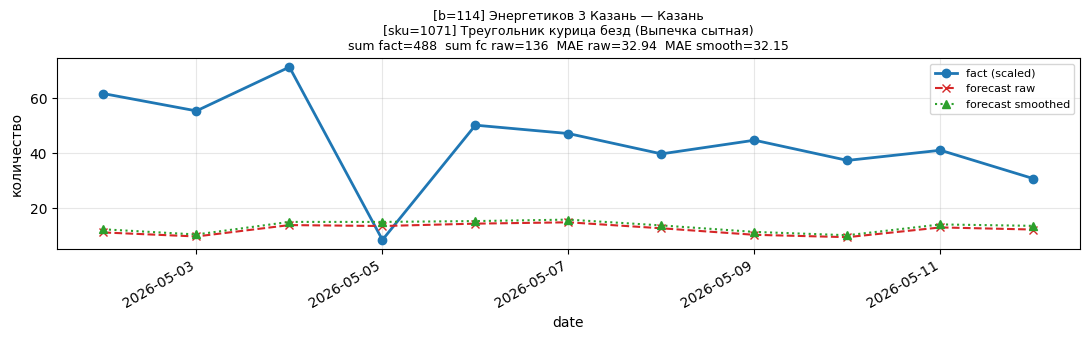

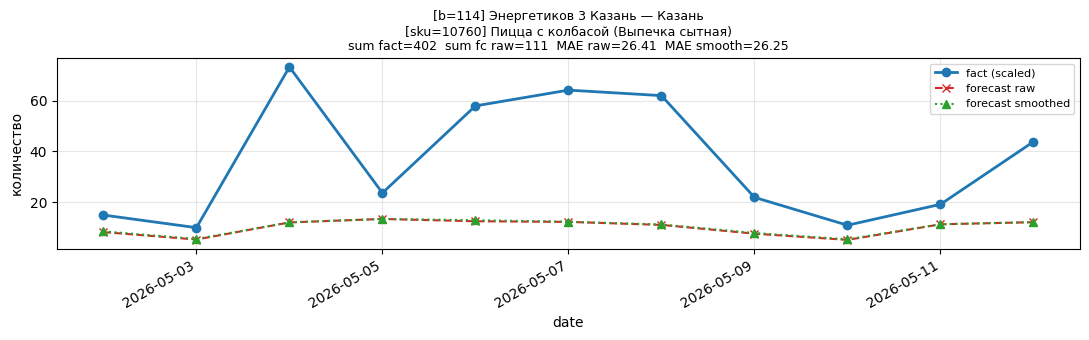

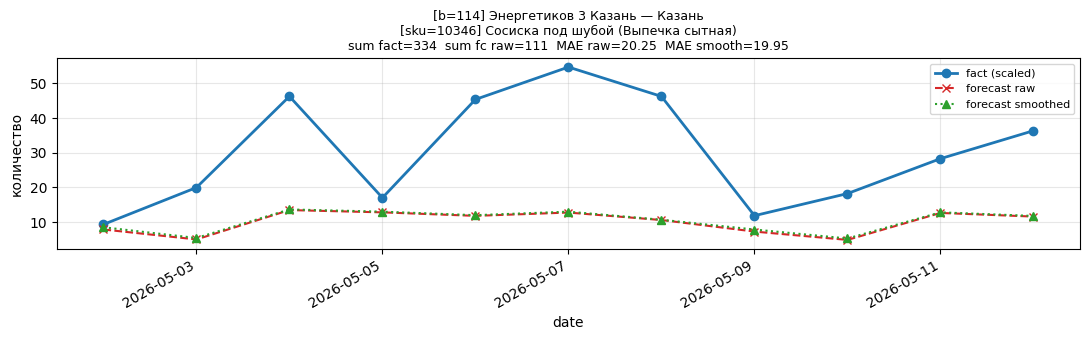

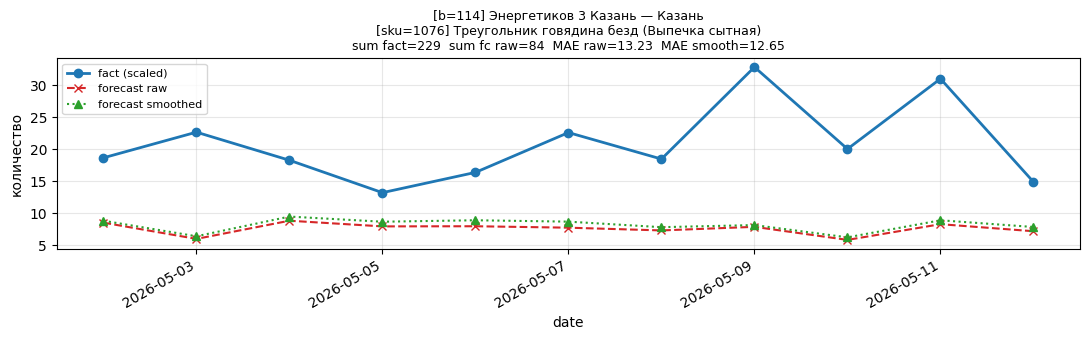

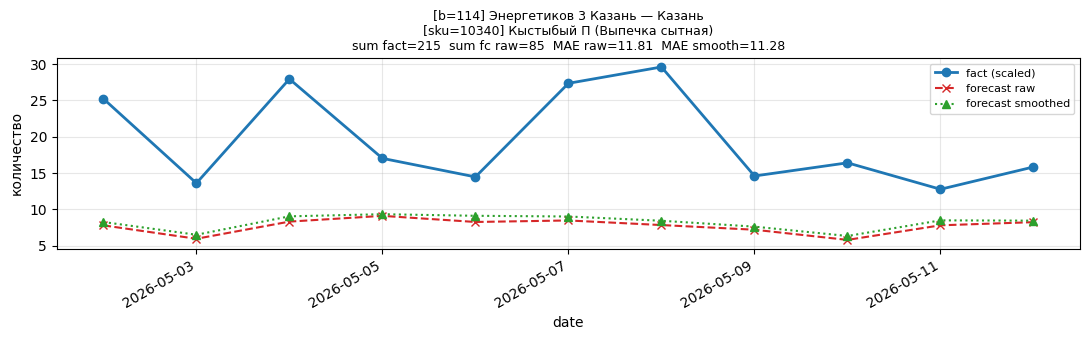

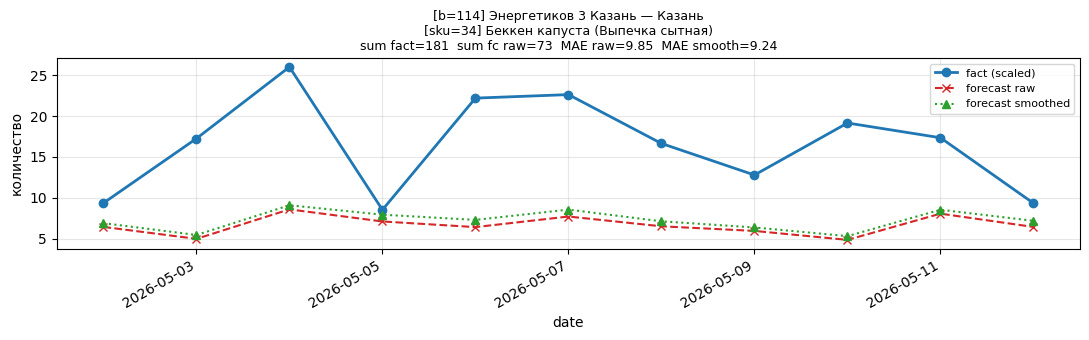

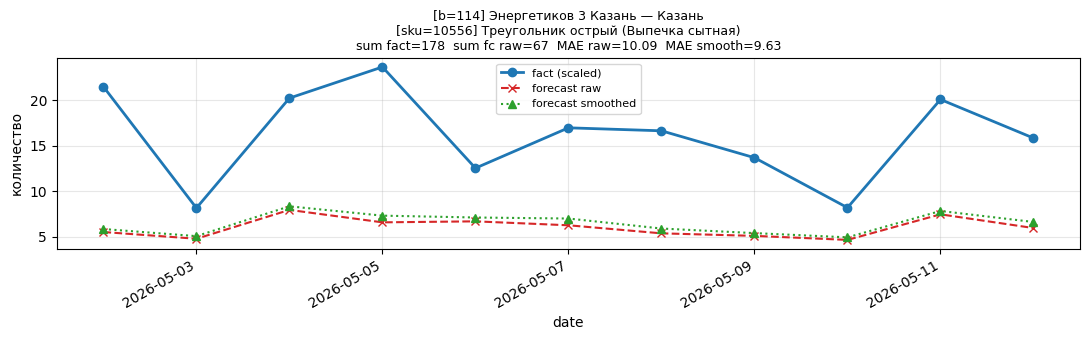

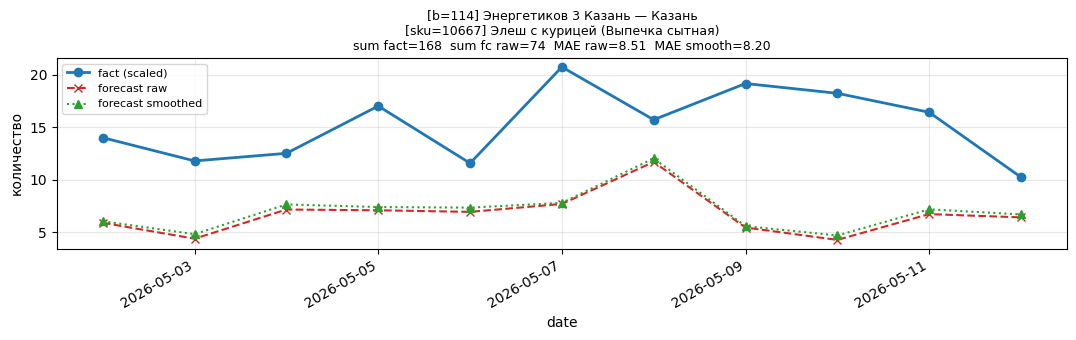

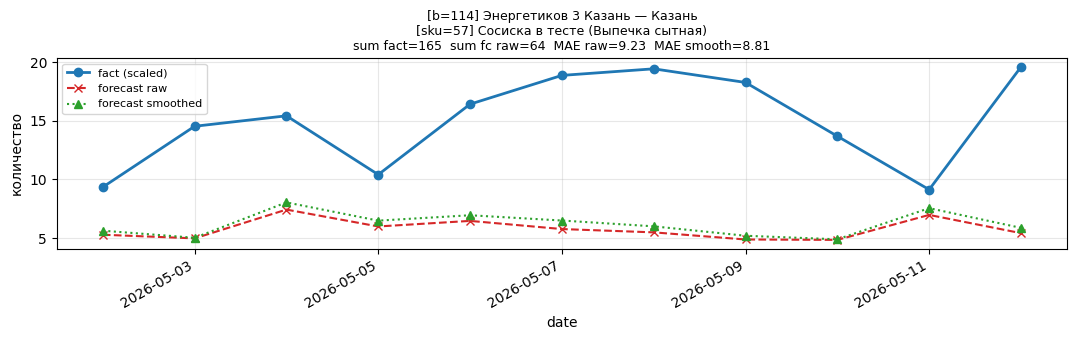

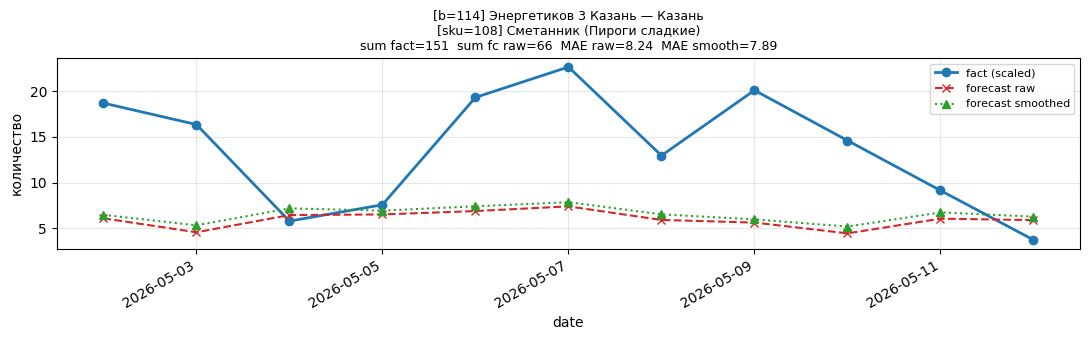

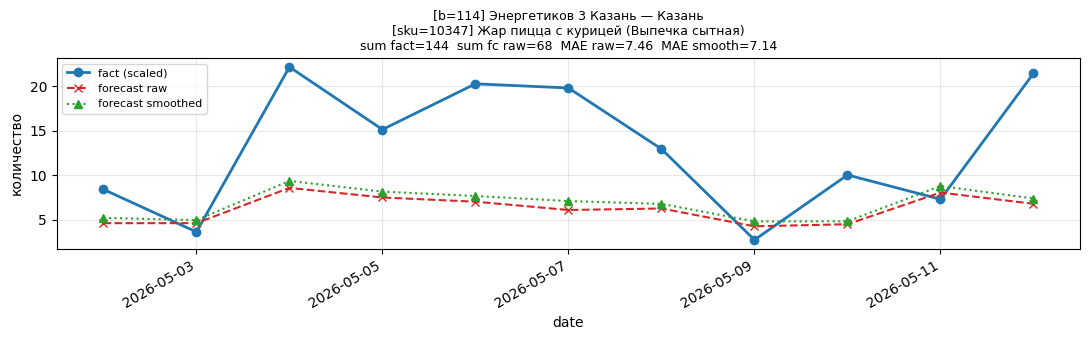

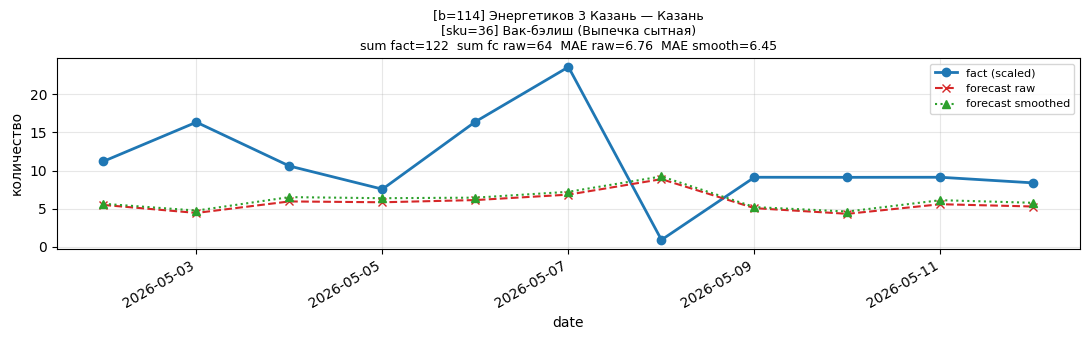

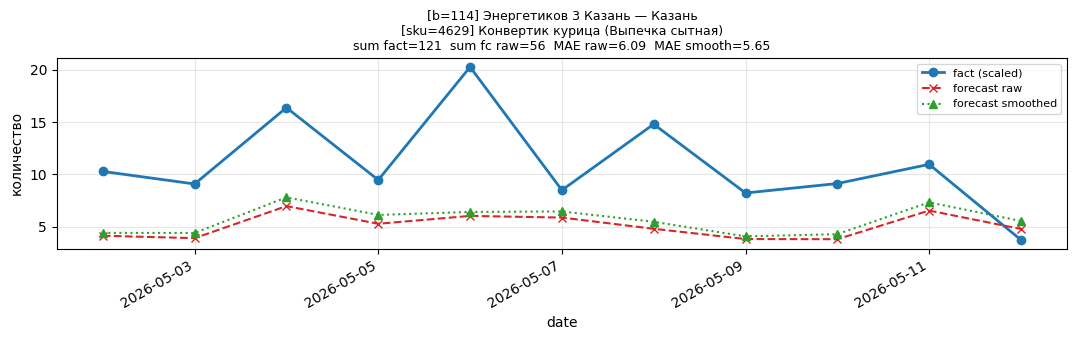

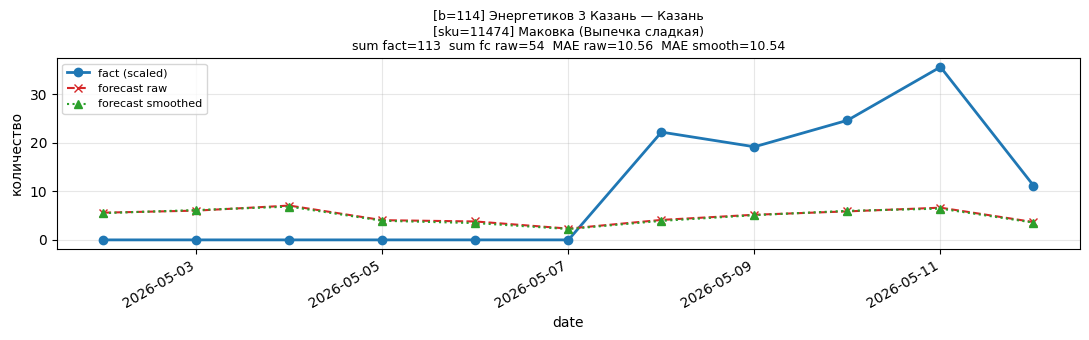

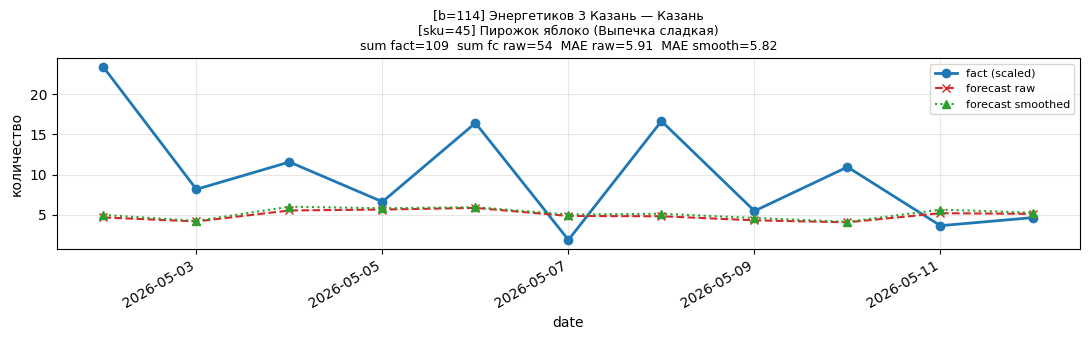

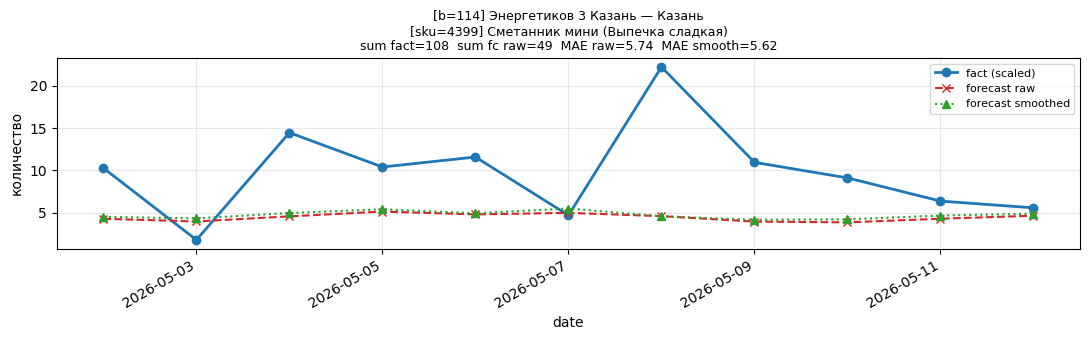

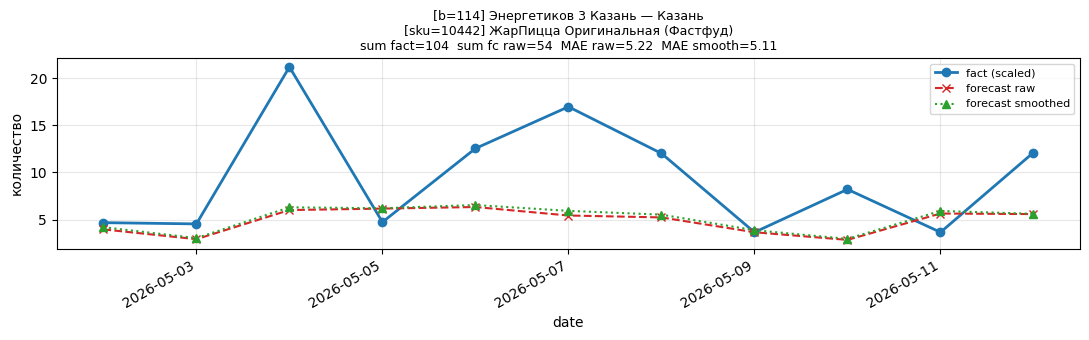

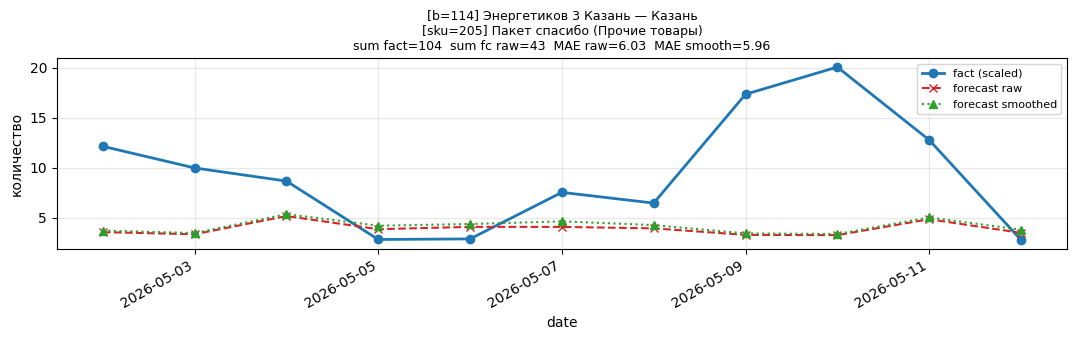

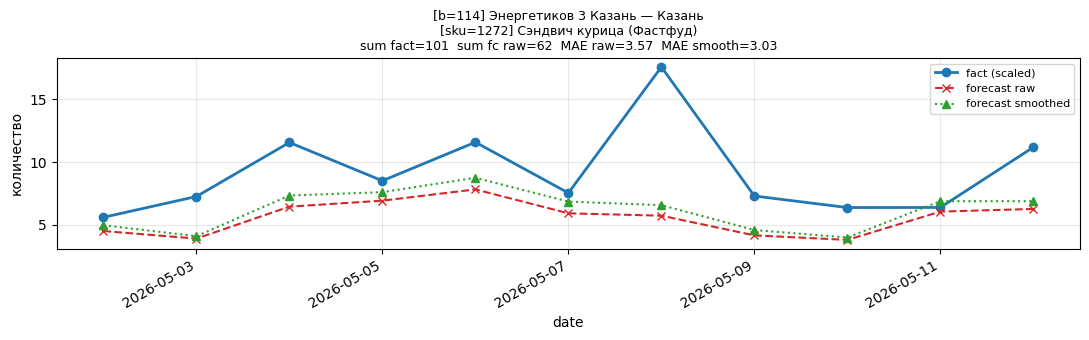

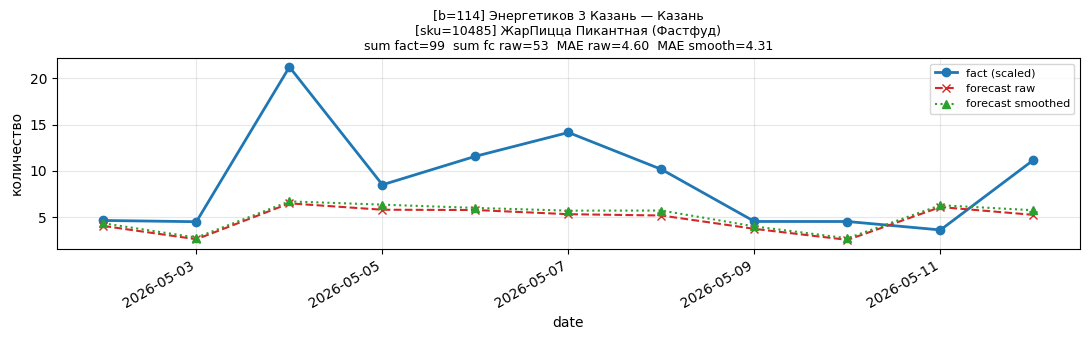


=== bakery 30, top-20 SKU по mean_fact ===


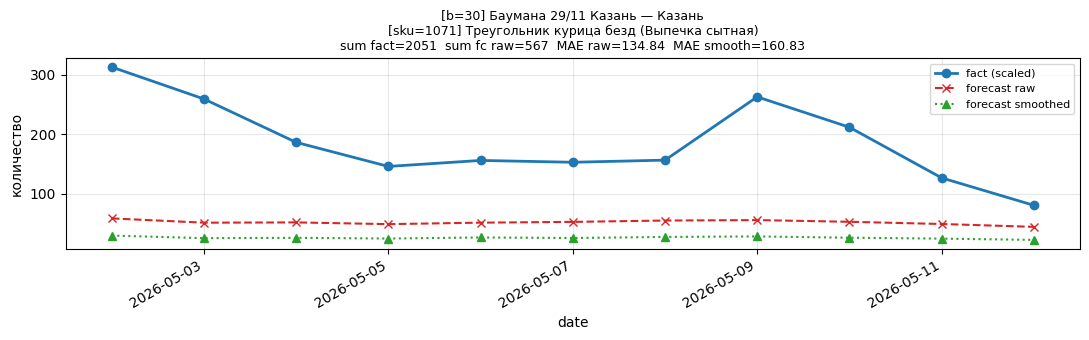

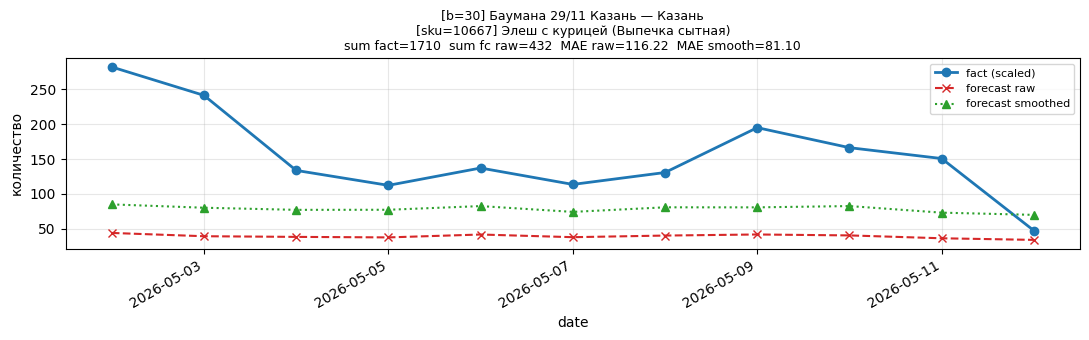

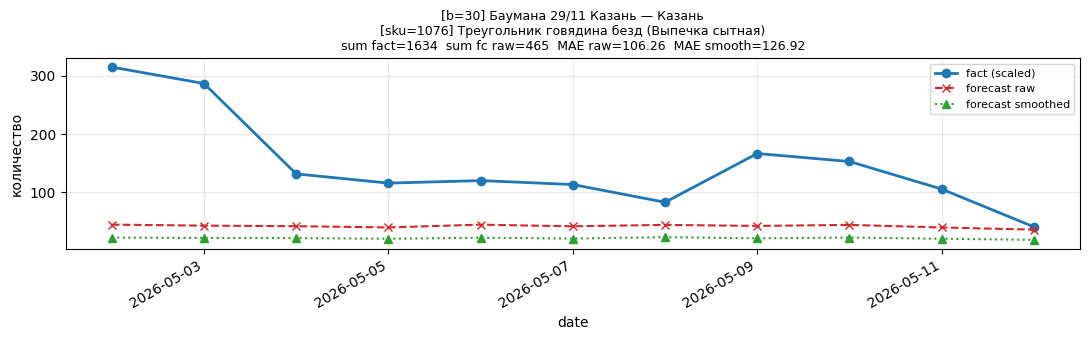

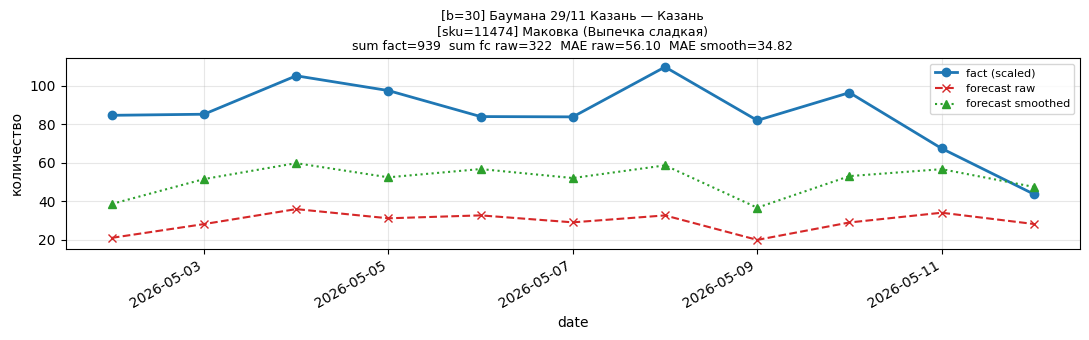

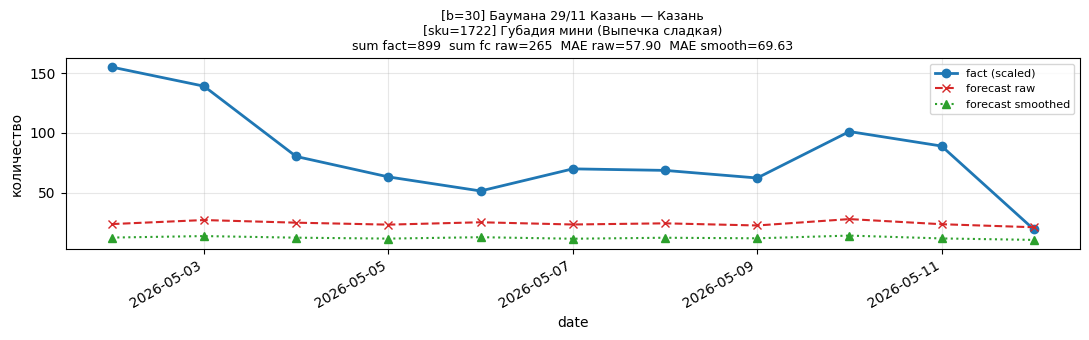

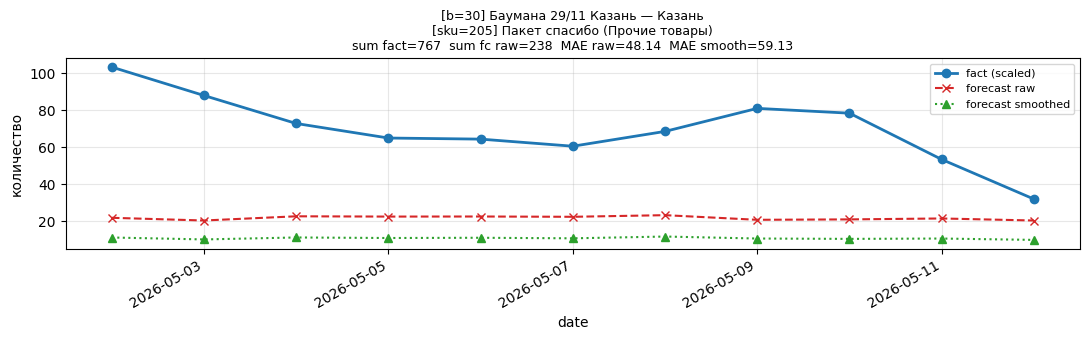

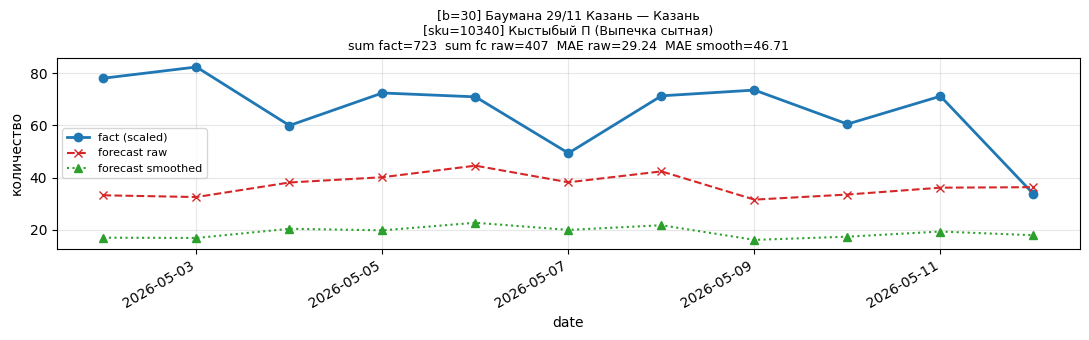

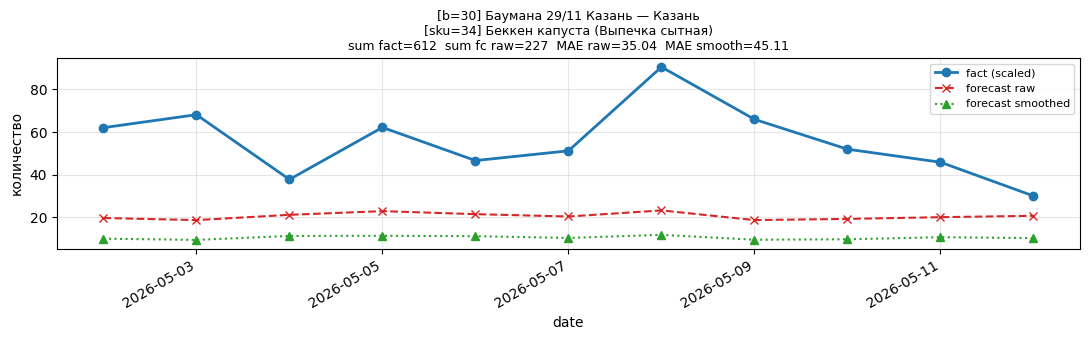

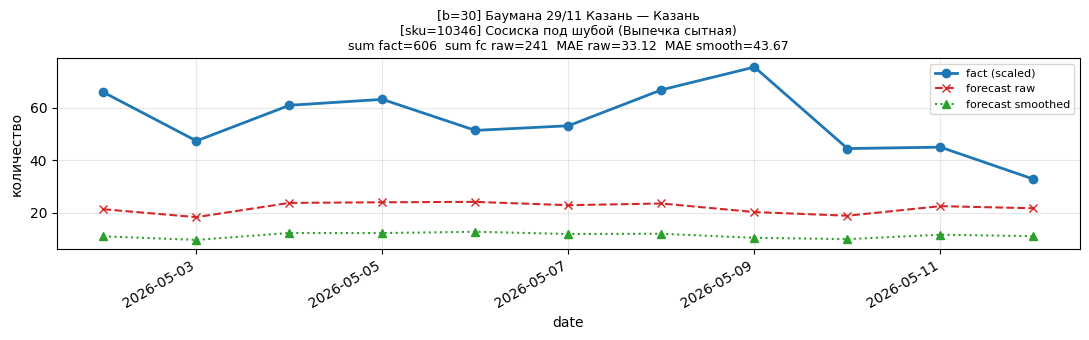

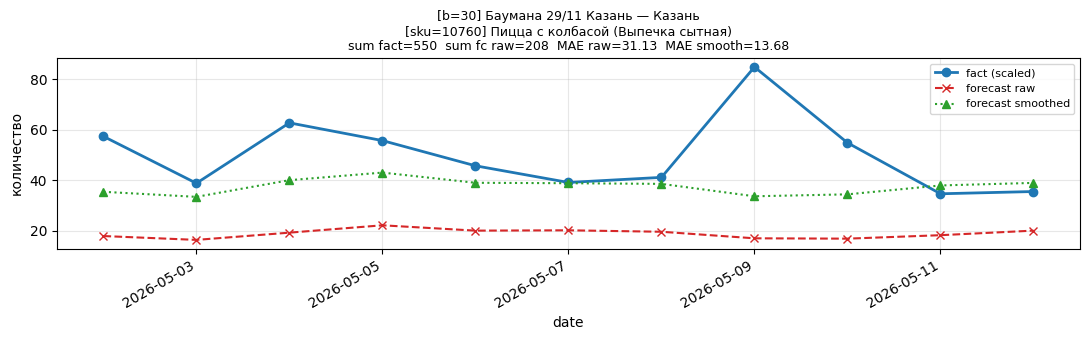

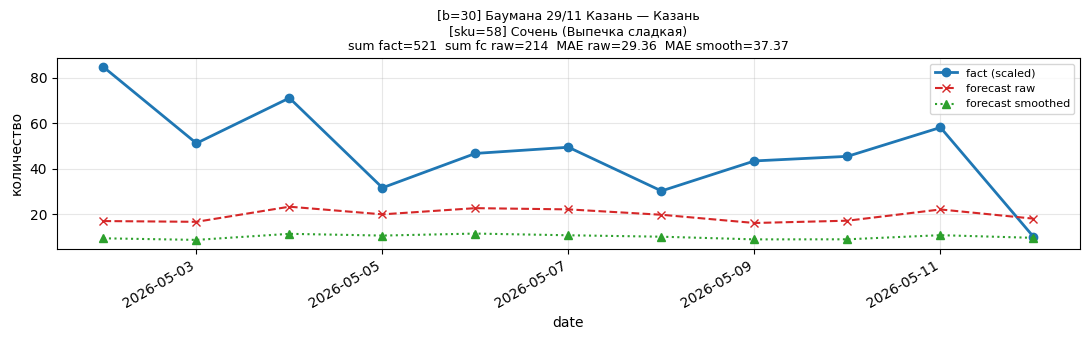

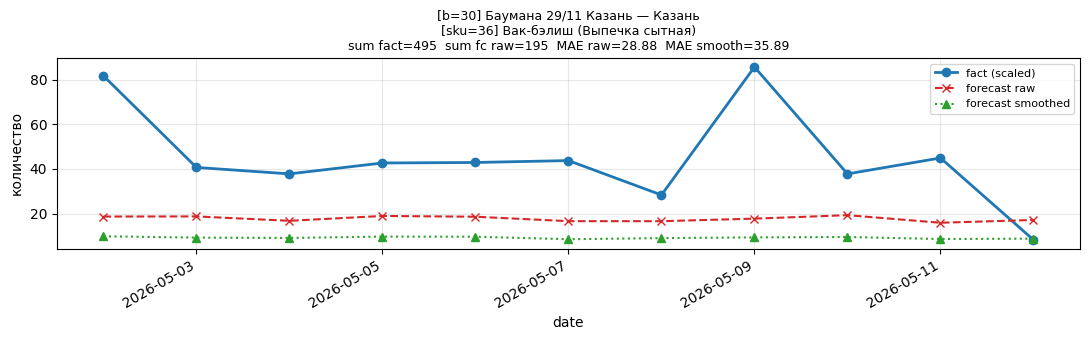

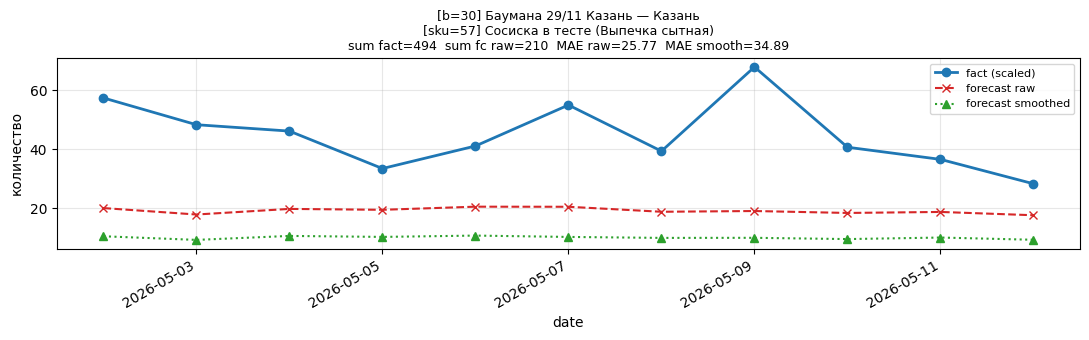

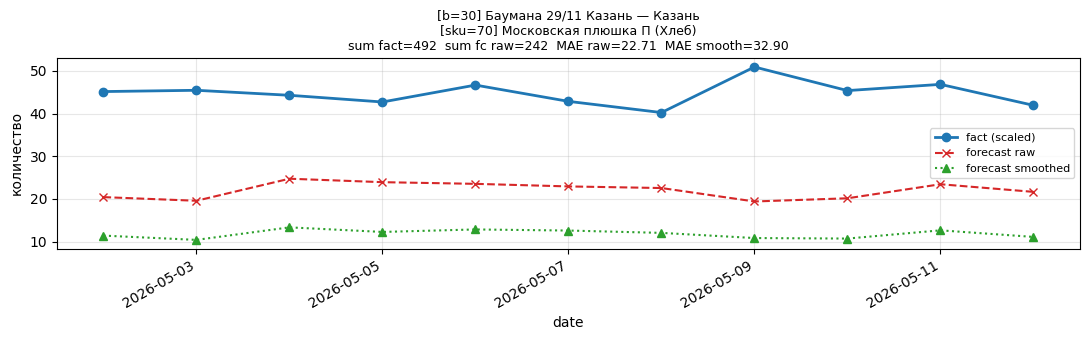

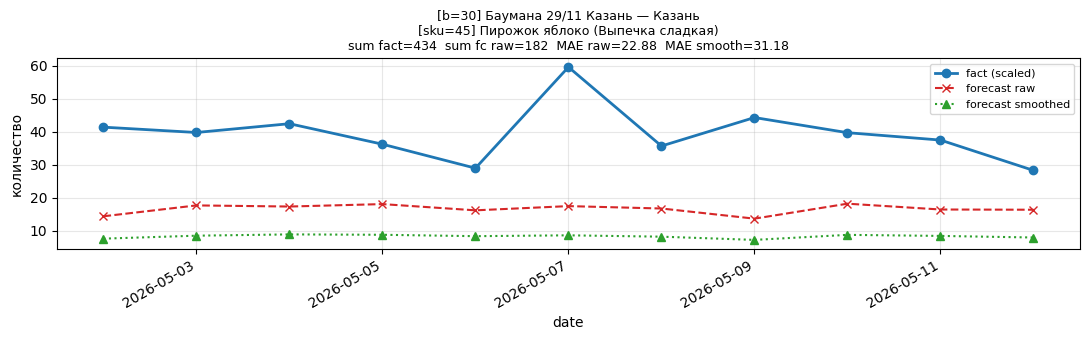

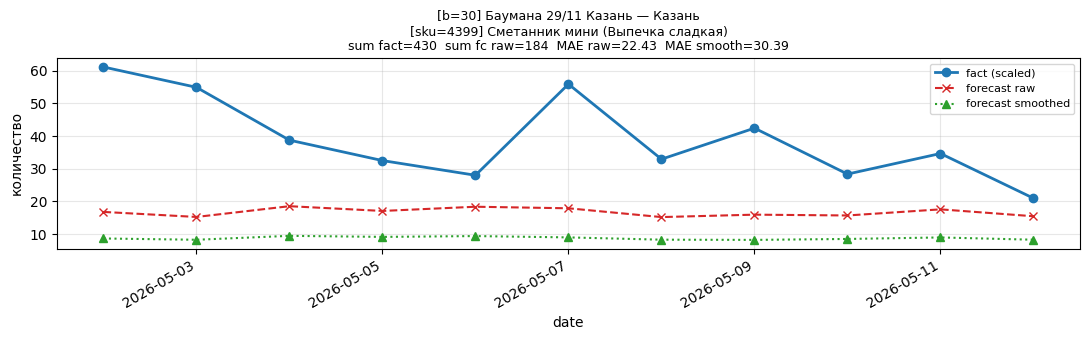

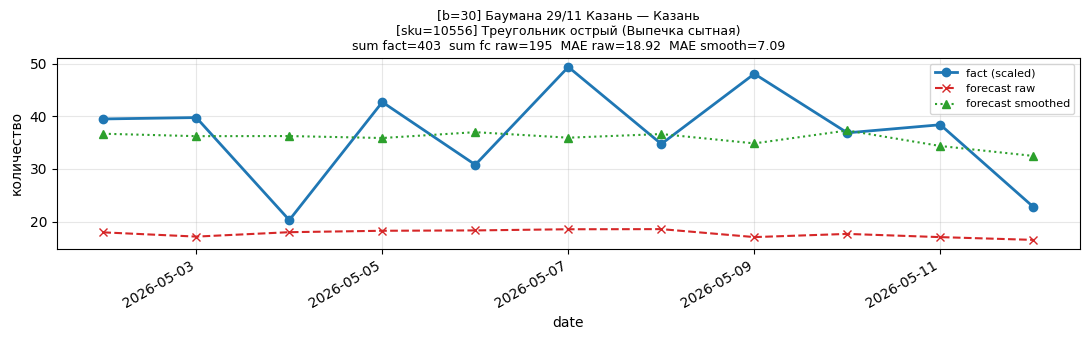

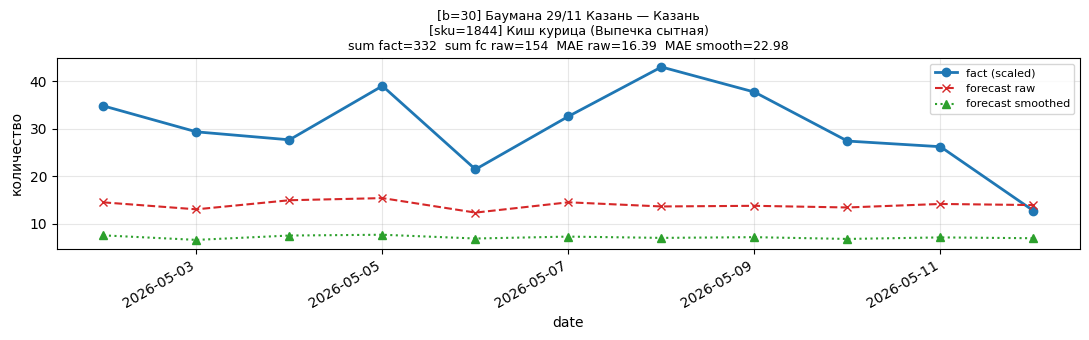

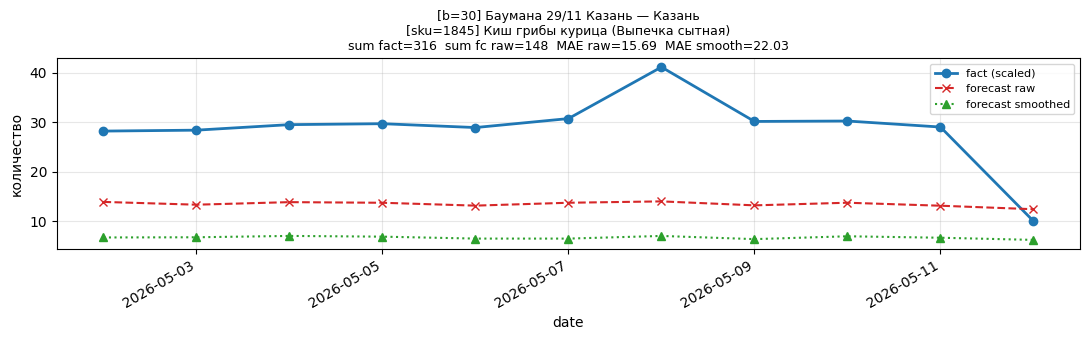

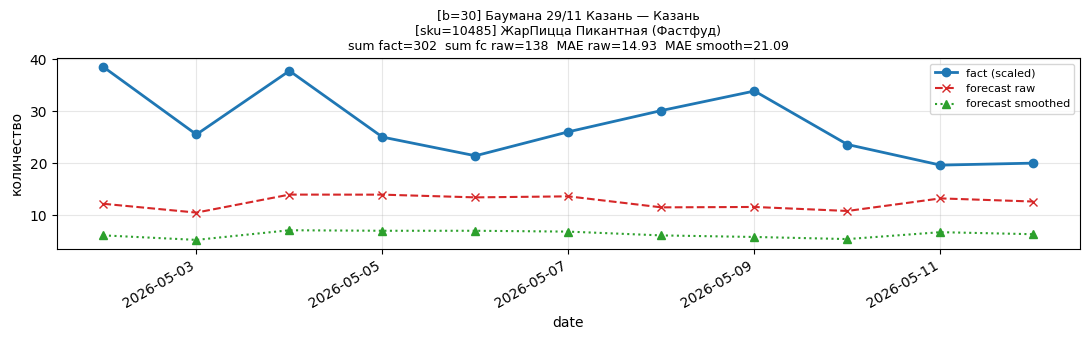

bakery 250 нет в данных, пропуск

Сохраняю PNG для всех 182 пекарен × top-20 SKU...
Готово. PNG сохранено: 3640 в c:\Users\dns\Desktop\Projects\demand-forecasting-model\reports\holdout_sku_charts


In [8]:
TOP_SKU_PER_BAKERY = 20
SHOW_FOR_BAKERIES = [114, 30, 250]  # 114 = smoke partner; 30 = большой over-error из table cells; 250 = худший bakery в WMAPE base
SAVE_ALL_PNGS = True

by_pair_sorted = by_pair.sort_values(
    ["bakery_id", "mean_fact"], ascending=[True, False]
)

def plot_sku(bakery_id, product_id, *, save_only=False):
    g = df[(df["bakery_id"] == bakery_id) & (df["product_id"] == product_id)].sort_values("date")
    if g.empty:
        return
    name = g["product_name"].iloc[0] if pd.notna(g["product_name"].iloc[0]) else f"product {product_id}"
    cat = g["category_name"].iloc[0] if pd.notna(g["category_name"].iloc[0]) else ""
    bn = g["bakery_name"].iloc[0]
    city = g["city"].iloc[0]
    mae_r = g["abs_err_raw"].mean()
    mae_s = g["abs_err_smoothed"].mean()
    sumf = g["fact"].sum()
    sumr = g["forecast_raw"].sum()

    fig, ax = plt.subplots(figsize=(11, 3.5))
    ax.plot(g["date"], g["fact"],              label="fact (scaled)",         color="#1f77b4", linewidth=2, marker="o")
    ax.plot(g["date"], g["forecast_raw"],      label="forecast raw",          color="#d62728", linestyle="--", marker="x")
    ax.plot(g["date"], g["forecast_smoothed"], label="forecast smoothed",     color="#2ca02c", linestyle=":",  marker="^")
    ax.set_title(
        f"[b={bakery_id}] {bn} — {city}\n"
        f"[sku={product_id}] {name} ({cat})\n"
        f"sum fact={sumf:.0f}  sum fc raw={sumr:.0f}  MAE raw={mae_r:.2f}  MAE smooth={mae_s:.2f}",
        fontsize=9,
    )
    ax.set_xlabel("date"); ax.set_ylabel("количество")
    ax.legend(loc="best", fontsize=8); ax.grid(True, alpha=0.3)
    fig.autofmt_xdate(); fig.tight_layout()
    out_dir = CHARTS_DIR / f"bakery_{bakery_id:04d}"
    out_dir.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_dir / f"sku_{product_id:05d}.png", dpi=110)
    if save_only:
        plt.close(fig)
    else:
        plt.show()

# Show examples for chosen bakeries
for bid in SHOW_FOR_BAKERIES:
    if bid not in df["bakery_id"].values:
        print(f"bakery {bid} нет в данных, пропуск")
        continue
    bsku = by_pair_sorted[by_pair_sorted["bakery_id"] == bid].head(TOP_SKU_PER_BAKERY)
    print(f"\n=== bakery {bid}, top-{len(bsku)} SKU по mean_fact ===")
    for pid in bsku["product_id"]:
        plot_sku(bid, int(pid))

# Save PNGs for all bakeries (silently)
if SAVE_ALL_PNGS:
    n_pngs = 0
    bakeries = sorted(df["bakery_id"].unique())
    print(f"\nСохраняю PNG для всех {len(bakeries)} пекарен × top-{TOP_SKU_PER_BAKERY} SKU...")
    for bid in bakeries:
        bsku = by_pair_sorted[by_pair_sorted["bakery_id"] == bid].head(TOP_SKU_PER_BAKERY)
        for pid in bsku["product_id"]:
            # уже нарисованные в ноутбуке тоже досохраняются
            plot_sku(bid, int(pid), save_only=True)
            n_pngs += 1
    print(f"Готово. PNG сохранено: {n_pngs} в {CHARTS_DIR}")

## 8. Конкретная пара (bakery, product)

Меняй id, перезапускай.

In [ ]:
BAKERY_ID = 30
PRODUCT_ID = 1076
plot_sku(BAKERY_ID, PRODUCT_ID)

## 9. Per-bakery SKU summary

Какие пекарни имеют наибольшую SKU-ошибку относительно своего объёма.

In [ ]:
by_bakery = df.groupby(["bakery_id", "bakery_name", "city"], group_keys=False).apply(
    lambda g: pd.Series({
        "rows":           len(g),
        "products":       g["product_id"].nunique(),
        "sum_fact":       g["fact"].sum(),
        "sum_fc_raw":     g["forecast_raw"].sum(),
        "wmape_raw":      g["abs_err_raw"].sum() / max(g["fact"].sum(), 1) * 100,
        "wmape_smoothed": g["abs_err_smoothed"].sum() / max(g["fact"].sum(), 1) * 100,
        "share_dead_err": (
            g.loc[(g["forecast_raw"] > EPS) & (g["fact"] <= EPS), "abs_err_raw"].sum()
            / max(g["abs_err_raw"].sum(), 1) * 100
        ),
    })
).reset_index().sort_values("wmape_raw", ascending=False)
print("Худшие 15 по WMAPE SKU raw:")
by_bakery.head(15).round(2)